# DistilBERT baseline

This notebook fine-tunes DistilBERT as a binary classifier on the [`rasbt/human-vs-ai-50k`](https://huggingface.co/datasets/rasbt/human-vs-ai-50k) dataset. It follows the same train, calibrate, evaluate, and export structure as the scikit-learn baseline.

From the project directory, install the dependencies with `uv sync --group dev` and open the notebook with `uv run jupyter lab scripts/07_distilbert/distilbert.ipynb`. The first model-loading cell downloads the pretrained DistilBERT weights if they are not already cached.

In [1]:
import json
import platform
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
)
import transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

PyTorch version: 2.13.0+cu130
Transformers version: 5.14.1
Device: cuda


## Load the dataset

In [3]:
dataset = load_dataset("rasbt/human-vs-ai-50k")

train_dataset = dataset["train"]
validation_dataset = dataset["validation"]
test_dataset = dataset["test"]

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'split', 'group_id', 'local_file', 'word_count', 'sha256', 'sample_type', 'text_collection', 'source_collection', 'source_document_id', 'source_name', 'source_title', 'source_url', 'source_license', 'source_license_url', 'source_authors', 'attribution_name', 'attribution_url', 'generator_provider', 'generator_model', 'seed_sample_id', 'target_words', 'public_hub_eligible'],
        num_rows: 40559
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'split', 'group_id', 'local_file', 'word_count', 'sha256', 'sample_type', 'text_collection', 'source_collection', 'source_document_id', 'source_name', 'source_title', 'source_url', 'source_license', 'source_license_url', 'source_authors', 'attribution_name', 'attribution_url', 'generator_provider', 'generator_model', 'seed_sample_id', 'target_words', 'public_hub_eligible'],
        num_rows: 5085
    })
    test: Dataset({
        features: ['

In [4]:
split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "human": split_dataset["label"].count(0),
            "ai": split_dataset["label"].count(1),
            "total": len(split_dataset),
        }
        for split_name, split_dataset in dataset.items()
    ]
).set_index("split")

split_summary

,human,ai,total
split,,,
train,20256,20303,40559
validation,2552,2533,5085
test,2547,2519,5066


## Tokenization

DistilBERT supports sequences of at most 512 tokens. Longer dataset samples are truncated to their first 512 tokens. Dynamic padding keeps shorter samples from being padded until a batch is assembled.

In [5]:
MODEL_NAME = "distilbert/distilbert-base-uncased"
MAX_LENGTH = 512
RANDOM_STATE = 17

set_seed(RANDOM_STATE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )


columns_to_remove = [
    column
    for column in train_dataset.column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

tokenized_dataset

Tokenizing:   0%|          | 0/5085 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 40559
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5085
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5066
    })
})

## Fine-tuning

The model is trained only on the training split. Validation accuracy selects the best epoch, and early stopping ends training if validation accuracy stops improving. The validation split is subsequently reused for temperature scaling, while the test split remains untouched until the final evaluation.

A full hyperparameter grid would require a separate fine-tuning run for every configuration. This baseline instead uses a conventional DistilBERT setup and selects among epochs.

In [6]:
id2label = {0: "HUMAN", 1: "AI"}
label2id = {"HUMAN": 0, "AI": 1}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)


def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}


use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

training_args = TrainingArguments(
    output_dir="checkpoints",
    learning_rate=5e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,
    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,
    report_to="none",
    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
train_result = trainer.train()

print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"Best validation accuracy: {trainer.state.best_metric:.2%}")

Epoch,Training Loss,Validation Loss,Accuracy
1,0.047372,0.032770,0.991937
2,0.011806,0.030155,0.994297
3,0.014920,0.008994,0.997443
4,0.001591,0.024674,0.996264


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint: checkpoints/checkpoint-7605
Best validation accuracy: 99.74%


## Temperature scaling

Temperature scaling learns one positive scalar from the validation logits. Dividing the logits by this temperature changes the confidence of the predictions without changing which class has the larger logit. A temperature above 1 softens the probabilities, while a temperature below 1 makes them more confident.

In [8]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)
validation_logits = np.asarray(validation_output.predictions)
y_validation = np.asarray(
    validation_dataset["label"], dtype=np.int64
)


def fit_temperature(logits, labels):
    logits_tensor = torch.tensor(logits, dtype=torch.float64)
    labels_tensor = torch.tensor(labels, dtype=torch.long)
    log_temperature = torch.nn.Parameter(
        torch.zeros((), dtype=torch.float64)
    )
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()
        temperature = log_temperature.exp()
        loss = criterion(logits_tensor / temperature, labels_tensor)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(log_temperature.exp().detach())


def probabilities_from_logits(logits, temperature=1.0):
    scaled_logits = np.asarray(logits, dtype=np.float64) / temperature
    scaled_logits -= scaled_logits.max(axis=1, keepdims=True)
    exponentiated = np.exp(scaled_logits)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)


TEMPERATURE = fit_temperature(validation_logits, y_validation)
print(f"Learned temperature: {TEMPERATURE:.4f}")

Learned temperature: 1.2900


In [9]:
uncalibrated_validation_probability = probabilities_from_logits(
    validation_logits
)[:, 1]
calibrated_validation_probability = probabilities_from_logits(
    validation_logits, TEMPERATURE
)[:, 1]

calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",
            "Brier score": brier_score_loss(
                y_validation, uncalibrated_validation_probability
            ),
            "Log loss": log_loss(
                y_validation, uncalibrated_validation_probability
            ),
        },
        {
            "model": "Temperature-scaled",
            "Brier score": brier_score_loss(
                y_validation, calibrated_validation_probability
            ),
            "Log loss": log_loss(
                y_validation, calibrated_validation_probability
            ),
        },
    ]
).set_index("model")

calibration_comparison.style.format("{:.4f}")

,Brier score,Log loss
model,,
Uncalibrated,0.0022,0.0090
Temperature-scaled,0.0021,0.0081


## Final evaluation

The following results use the temperature-scaled probabilities with a decision threshold of 0.5. Training results are fit-set diagnostics, while validation results reuse the checkpoint-selection and calibration set. The test split provides the final held-out evaluation.

The positive class is AI-generated text. A false positive is human text classified as AI, and a false negative is AI-generated text classified as human.

In [10]:
DECISION_THRESHOLD = 0.5

split_logits = {"validation": validation_logits}
for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )
    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def evaluate_split(split_name):
    y_true = np.asarray(dataset[split_name]["label"], dtype=np.int64)
    ai_probability = probabilities_from_logits(
        split_logits[split_name], TEMPERATURE
    )[:, 1]
    y_pred = (
        ai_probability >= DECISION_THRESHOLD
    ).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    return {
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, ai_probability),
        "log_loss": log_loss(y_true, ai_probability),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")

evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,true_negative,false_positive,false_negative,true_positive
split,,,,,,,
train,99.99%,0.0001,0.0013,20251,5,1,20302
validation,99.74%,0.0021,0.0081,2547,5,8,2525
test,99.70%,0.0024,0.0089,2538,9,6,2513


## Test-set confusion matrix

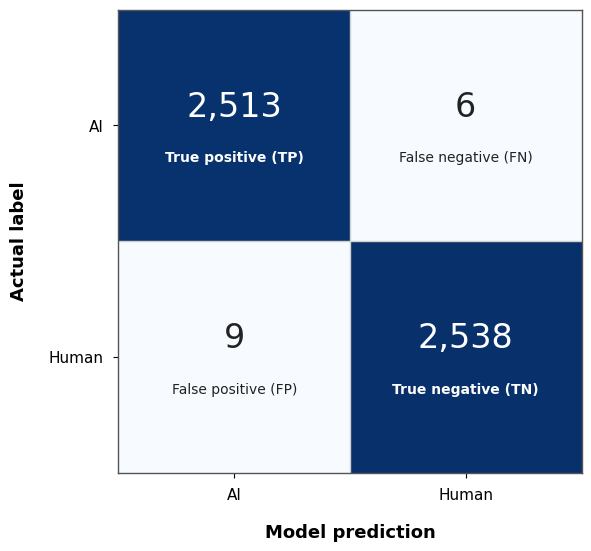

In [11]:
y_test = np.asarray(test_dataset["label"], dtype=np.int64)
y_test_ai_probability = probabilities_from_logits(
    split_logits["test"], TEMPERATURE
)[:, 1]
y_test_pred = (
    y_test_ai_probability >= DECISION_THRESHOLD
).astype(np.int64)

# AI is listed first so the matrix reads TP, FN, FP, TN.
test_matrix = confusion_matrix(
    y_test, y_test_pred, labels=[1, 0]
)
cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(test_matrix, cmap="Blues", vmin=0, vmax=test_matrix.max())

for row in range(2):
    for column in range(2):
        value = test_matrix[row, column]
        text_color = (
            "white" if value > test_matrix.max() / 2 else "#222222"
        )
        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )
        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight=(
                "bold"
                if value > test_matrix.max() / 2
                else "normal"
            ),
        )

ax.set_xticks([0, 1], labels=["AI", "Human"])
ax.set_yticks([0, 1], labels=["AI", "Human"])
ax.set_xlabel(
    "Model prediction", fontsize=13, fontweight="bold", labelpad=15
)
ax.set_ylabel(
    "Actual label", fontsize=13, fontweight="bold", labelpad=15
)
ax.axhline(0.5, color="#d0d0d0", linewidth=1)
ax.axvline(0.5, color="#d0d0d0", linewidth=1)
ax.tick_params(axis="both", labelsize=11, pad=7)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()
plt.savefig("distilbert-confmat.svg")
plt.show()

## Inspect confident test-set errors

This table makes it easier to check whether the model relies on dataset artifacts or struggles with particular text sources. The confidence column is the probability assigned to the predicted class.

In [12]:
test_errors = pd.DataFrame(
    {
        "id": test_dataset["id"],
        "actual": np.where(y_test == 1, "AI", "Human"),
        "prediction": np.where(y_test_pred == 1, "AI", "Human"),
        "ai_probability": y_test_ai_probability,
        "source_collection": test_dataset["source_collection"],
        "generator_model": test_dataset["generator_model"],
        "text": [text[:300] for text in test_dataset["text"]],
    }
)
test_errors = test_errors[test_errors["actual"] != test_errors["prediction"]].copy()
test_errors["prediction_confidence"] = np.where(
    test_errors["prediction"] == "AI",
    test_errors["ai_probability"],
    1.0 - test_errors["ai_probability"],
)

test_errors.sort_values(
    "prediction_confidence", ascending=False
).head(20).style.format(
    {
        "ai_probability": "{:.2%}",
        "prediction_confidence": "{:.2%}",
    }
)

,id,actual,prediction,ai_probability,source_collection,generator_model,text,prediction_confidence
2263,22782,Human,AI,99.48%,wikimedia,None,"in exchange for a first-round pick in the 2022 NWSL Draft, a natural third-round pick in the 2023 NWSL Draft, and $50,000 in allocation money. On December 6, 2021, Tierna Davidson, Casey Krueger, Alyssa Naeher and Mallory Pugh relinquished their federation player status and signed multi-year contrac",99.48%
2535,25258,Human,AI,97.36%,stackexchange,None,"This solution provides a strict FixedLengthArray (ak.a. SealedArray) type signature based in Tuples. (*) This solution requires the typescript configuration directive to be enabled in order to work (commonly recommended practice) This solution behaves as an augmentation of the type, accepting an add",97.36%
2024,20513,Human,AI,96.30%,arxiv,None,"speech recognition network e2e Experiment experiments Conclusion In this work, we have scaled up the capacity of the multi-lingual ASR network with sparsely gated MoE. The MoE method used in this work increases computational complexity only for gating calculation; an increase in computational comple",96.30%
3735,37237,AI,Human,5.18%,gutenberg,deepseek-v4-flash-0731,"When everything is stripped away, I stand before you with nothing but the truth of my failures. I ask not for absolution, but for your patience as I earn back what I’ve broken. Let my shame be the first payment on a debt I owe to you all.",94.82%
3379,33790,AI,Human,6.01%,wikimedia,deepseek-v4-flash-0731,"Ra McGuire and Brian Smith played in the late-1960s Vancouver band The Chessmen. That group recorded two singles on the Rumble Records label: ""I Can't Get Through to You"" (released in 1966) and ""I Need Your Lovin'"" (from 1967). The Chessmen were a prominent local garage-rock act before McGuire and S",93.99%
2307,23187,Human,AI,93.85%,wikimedia,None,"The 2013/14 season saw Walsall finish 13th in League One. The campaign was most notable for the Saddlers' meetings with Black Country rivals Wolves, including a 1–0 away at Molineux. The summer of 2013 saw the Saddlers lose the attacking trio of Will Grigg, Febian Brandy and Jamie Paterson, who had",93.85%
1842,18216,Human,AI,92.75%,arxiv,None,samples . Simply Connected Sample Space\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \,92.75%
2302,23117,Human,AI,91.94%,wikimedia,None,"""The Boy with the Thorn in His Side"" is a song by the English rock band the Smiths. It was released as a single in September 1985, reaching No. 23 in the UK Singles Chart. A remixed version appeared on their third album The Queen Is Dead in June 1986.",91.94%
3741,37294,AI,Human,9.30%,plos,deepseek-v4-flash-0731,"To prepare fixed brain tissue for fluorescence microscopy, cryoprotect the tissue by incubating in 30% sucrose in PBS until it sinks, then embed in optimal cutting temperature (OCT) compound and freeze. Section on a cryostat (typically 20–40 µm thick), collecting slices onto charged slides. After th",90.70%
4214,41912,AI,Human,12.13%,openstax,moonshotai/kimi-k3,"The Hartford Convention was a series of meetings held by Federalist delegates from Massachusetts, Connecticut, and Rhode Island, with a few counties from New Hampshire and Vermont sending unofficial representatives, in Hartford, Connecticut, from December 15, 1814, to January 5, 1815. It arose from",87.87%


## Export the calibrated model

The exported directory contains the best DistilBERT checkpoint, tokenizer, learned temperature, decision threshold, and package versions. The temperature must be applied to the logits before converting them to probabilities.

In [13]:
ARTIFACT_DIR = Path("artifacts") / "distilbert-ai-detector"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(ARTIFACT_DIR)
tokenizer.save_pretrained(ARTIFACT_DIR)

metadata = {
    "dataset": "rasbt/human-vs-ai-50k",
    "base_model": MODEL_NAME,
    "label_mapping": {"human": 0, "ai": 1},
    "max_length": MAX_LENGTH,
    "decision_threshold": DECISION_THRESHOLD,
    "calibration": "temperature scaling",
    "temperature": TEMPERATURE,
    "best_validation_accuracy": float(trainer.state.best_metric),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "random_state": RANDOM_STATE,
    "python_version": platform.python_version(),
    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}

METADATA_PATH = ARTIFACT_DIR / "detector-config.json"
METADATA_PATH.write_text(
    json.dumps(metadata, indent=2) + "\n",
    encoding="utf-8",
)

print(f"Saved model and tokenizer to {ARTIFACT_DIR}")
print(f"Saved detector configuration to {METADATA_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to artifacts/distilbert-ai-detector
Saved detector configuration to artifacts/distilbert-ai-detector/detector-config.json


## Load the model in a script

The helper below accepts raw strings and returns the calibrated probability that each text is AI-generated.

In [14]:
loaded_tokenizer = AutoTokenizer.from_pretrained(ARTIFACT_DIR)
loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)
loaded_config = json.loads(METADATA_PATH.read_text(encoding="utf-8"))

if torch.cuda.is_available():
    inference_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    inference_device = torch.device("mps")
else:
    inference_device = torch.device("cpu")

loaded_model.to(inference_device)
loaded_model.eval()


def predict_ai_probability(texts):
    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    ).to(inference_device)
    with torch.inference_mode():
        logits = loaded_model(**inputs).logits
        calibrated_logits = logits / loaded_config["temperature"]
        return calibrated_logits.softmax(dim=1)[:, 1].cpu().numpy()


texts = ["Replace this string with the text you want to classify."]
ai_probabilities = predict_ai_probability(texts)

for text, ai_probability in zip(texts, ai_probabilities):
    prediction = int(
        ai_probability >= loaded_config["decision_threshold"]
    )
    label = "AI" if prediction == 1 else "Human"
    print(f"{label}: {ai_probability:.1%} AI probability | {text}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Human: 0.2% AI probability | Replace this string with the text you want to classify.
